In [1]:
# ==============================================================================
# Satellite Image Classification (No Pretrained) — Residual + SE + MixUp/CutMix
# Accuracy-tuned: warmup+cosine LR, proper val normalization, top-2 metric
# ==============================================================================

In [2]:
import os, numpy as np, tensorflow as tf, matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras import layers as L
from tensorflow.keras import regularizers

2025-10-31 14:21:54.286794: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761920514.471948      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761920514.523325      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
SEED        = 42
IMG_SIZE    = 192
BATCH_SIZE  = 32
EPOCHS      = 40
NUM_CLASSES = 4
DATA_DIR    = "/kaggle/input/satellite-image-classification/data"

tf.random.set_seed(SEED)
np.random.seed(SEED)
AUTOTUNE = tf.data.AUTOTUNE

In [4]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=0.2, subset="training", seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, label_mode="categorical"
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=0.2, subset="validation", seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, label_mode="categororical"
) if False else tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=0.2, subset="validation", seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, label_mode="categorical"
)
class_names = train_ds.class_names
assert len(class_names)==NUM_CLASSES, f"Found {len(class_names)} classes {class_names} but NUM_CLASSES={NUM_CLASSES}"

Found 5631 files belonging to 4 classes.
Using 4505 files for training.


I0000 00:00:1761920529.984892      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 5631 files belonging to 4 classes.
Using 1126 files for validation.


In [5]:
augment = tf.keras.Sequential([
    L.RandomFlip("horizontal"),
    L.RandomRotation(0.10),
    L.RandomZoom(0.15),
    L.RandomTranslation(0.10, 0.10),
    L.RandomContrast(0.12),
], name="augment")

def sample_beta(alpha=0.2):
    u1 = tf.random.gamma(shape=[], alpha=alpha, beta=1.0)
    u2 = tf.random.gamma(shape=[], alpha=alpha, beta=1.0)
    return u1 / (u1 + u2)

def mixup_cutmix_batch(images, labels, p_mixup=0.35, p_cutmix=0.20, alpha=0.2):
    bs = tf.shape(images)[0]
    idx = tf.random.shuffle(tf.range(bs))
    images2 = tf.gather(images, idx)
    labels2 = tf.gather(labels, idx)
    r = tf.random.uniform([])

    if r < p_mixup:
        lam = sample_beta(alpha)
        return lam*images + (1.0-lam)*images2, lam*labels + (1.0-lam)*labels2

    if r < p_mixup + p_cutmix:
        lam = sample_beta(alpha)
        h, w = tf.shape(images)[1], tf.shape(images)[2]
        cut_rat = tf.sqrt(1.0 - lam)
        cut_h = tf.cast(cut_rat * tf.cast(h, tf.float32), tf.int32)
        cut_w = tf.cast(cut_rat * tf.cast(w, tf.float32), tf.int32)
        cy = tf.random.uniform([], 0, h, dtype=tf.int32)
        cx = tf.random.uniform([], 0, w, dtype=tf.int32)
        y1 = tf.clip_by_value(cy - cut_h//2, 0, h); y2 = tf.clip_by_value(cy + cut_h//2, 0, h)
        x1 = tf.clip_by_value(cx - cut_w//2, 0, w); x2 = tf.clip_by_value(cx + cut_w//2, 0, w)

        c = tf.shape(images)[-1]
        mask = tf.ones((bs, y2-y1, x2-x1, c), dtype=images.dtype)
        mask = tf.pad(mask, [[0,0],[y1, h-y2],[x1, w-x2],[0,0]], constant_values=0)
        images_mix = images * (1 - mask) + images2 * mask

        lam_adj = 1.0 - tf.cast((y2 - y1) * (x2 - x1), tf.float32) / tf.cast(h*w, tf.float32)
        labels_mix = lam_adj*labels + (1.0-lam_adj)*labels2
        return images_mix, labels_mix

    return images, labels

def preprocess_train(images, labels):
    images = tf.cast(images, tf.float32) / 255.0
    images = augment(images)
    return images, labels

def preprocess_val(images, labels):
    images = tf.cast(images, tf.float32) / 255.0
    return images, labels

In [6]:
train_ds = train_ds.map(preprocess_train, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.map(lambda x,y: mixup_cutmix_batch(x,y), num_parallel_calls=AUTOTUNE)
train_ds = train_ds.shuffle(2048, seed=SEED).prefetch(AUTOTUNE)
val_ds   = val_ds.map(preprocess_val,   num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

In [7]:
WD = 1e-4
Act = tf.nn.silu

In [8]:
def ConvBN(x, filters, k=3, s=1, depthwise=False, name=None):
    if depthwise:
        x = L.DepthwiseConv2D(k, strides=s, padding="same",
                              depthwise_regularizer=regularizers.l2(WD),
                              use_bias=False, name=None if name is None else name+"_dw")(x)
        x = L.BatchNormalization()(x); x = L.Activation(Act)(x)
        x = L.Conv2D(filters, 1, padding="same", use_bias=False,
                     kernel_regularizer=regularizers.l2(WD),
                     name=None if name is None else name+"_pw")(x)
        x = L.BatchNormalization()(x); x = L.Activation(Act)(x)
        return x
    else:
        x = L.Conv2D(filters, k, strides=s, padding="same", use_bias=False,
                     kernel_regularizer=regularizers.l2(WD), name=name)(x)
        x = L.BatchNormalization()(x); x = L.Activation(Act)(x)
        return x

In [9]:
def SE(x, r=8):
    c = x.shape[-1]
    se = L.GlobalAveragePooling2D()(x)
    se = L.Dense(max(c//r, 4), activation=Act, kernel_regularizer=regularizers.l2(WD))(se)
    se = L.Dense(c, activation="sigmoid", kernel_regularizer=regularizers.l2(WD))(se)
    se = L.Reshape((1,1,c))(se)
    return L.Multiply()([x, se])

In [10]:
class StochasticDepth(L.Layer):
    def __init__(self, drop_prob): super().__init__(); self.drop_prob = drop_prob
    def call(self, x, training=None):
        if (not training) or self.drop_prob == 0.0: return x
        keep = 1.0 - self.drop_prob
        shape = (tf.shape(x)[0],) + (1,)*(len(x.shape)-1)
        binary = tf.cast(tf.random.uniform(shape) < keep, x.dtype)
        return x/keep * binary

In [11]:
def ResidualBlock(x, filters, stride=1, sep_depthwise=True, se_ratio=0.25, drop_path=0.0):
    shortcut = x; in_ch = x.shape[-1]
    x = ConvBN(x, filters//2, k=1, s=1)
    x = ConvBN(x, filters//2, k=3, s=stride, depthwise=sep_depthwise)
    x = ConvBN(x, filters, k=1, s=1)
    if se_ratio and se_ratio > 0: x = SE(x, r=int(1.0/se_ratio))
    if (stride != 1) or (in_ch != filters):
        shortcut = L.Conv2D(filters, 1, strides=stride, padding="same", use_bias=False,
                            kernel_regularizer=regularizers.l2(WD))(shortcut)
        shortcut = L.BatchNormalization()(shortcut)
    x = StochasticDepth(drop_path)(x)
    x = L.Add()([x, shortcut])
    return L.Activation(Act)(x)

In [12]:
def build_model(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES, base_width=48):
    inp = L.Input(shape=input_shape)
    x = ConvBN(inp, base_width, k=3, s=1)
    x = ConvBN(x, base_width, k=3, s=1)

    widths = [base_width*2, base_width*3, base_width*4, base_width*5]
    blocks = [2, 3, 4, 3]
    dp_rates = np.linspace(0.0, 0.20, sum(blocks))
    idx = 0
    for w, n in zip(widths, blocks):
        for b in range(n):
            stride = 2 if (b == 0) else 1
            x = ResidualBlock(x, w, stride=stride, sep_depthwise=True,
                              se_ratio=0.25, drop_path=float(dp_rates[idx]))
            idx += 1

    x = L.GlobalAveragePooling2D()(x)
    x = L.Dropout(0.40)(x)
    x = L.Dense(256, activation=Act, kernel_regularizer=regularizers.l2(WD))(x)
    x = L.Dropout(0.40)(x)
    out = L.Dense(num_classes, activation="softmax")(x)
    return tf.keras.Model(inp, out, name="SatScratchResSE")

In [13]:
model = build_model()
model.summary()

Model: "SatScratchResSE"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 192, 192,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 192, 192,  │      1,296 │ input_layer_1[0]… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 192, 192,  │        192 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 192, 192,  │          0 │ batch_normalizat… │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 192, 192,  │     20,736 │ activation[0][0]  │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 192, 192,  │        192 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 192, 192,  │          0 │ batch_normalizat… │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 192, 192,  │      2,304 │ activation_1[0][… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 192, 192,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 192, 192,  │          0 │ batch_normalizat… │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d    │ (None, 96, 96,    │        432 │ activation_2[0][… │
│ (DepthwiseConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96, 96,    │        192 │ depthwise_conv2d… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 96, 96,    │          0 │ batch_normalizat… │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 96, 96,    │      2,304 │ activation_3[0][… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96, 96,    │        192 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 96, 96,    │          0 │ batch_normalizat… │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 96, 96,    │      4,608 │ activation_4[0][

 Total params: 898,692 (3.43 MB)

 Trainable params: 886,596 (3.38 MB)

 Non-trainable params: 12,096 (47.25 KB)

In [14]:
steps_per_epoch = int(tf.data.experimental.cardinality(train_ds).numpy())
total_steps     = steps_per_epoch * EPOCHS
warmup_steps    = max(1, int(0.08 * total_steps))  # 8% warmup

@tf.keras.utils.register_keras_serializable(package="Custom")
class WarmupCosine(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, base_lr, total_steps, warmup_steps, min_lr_ratio=1e-2):
        super().__init__()
        self.base_lr = float(base_lr)
        self.total_steps = int(total_steps)
        self.warmup_steps = int(warmup_steps)
        self.min_lr_ratio = float(min_lr_ratio)

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        base = tf.cast(self.base_lr, tf.float32)
        min_lr = base * self.min_lr_ratio
        # warmup
        warm = base * (step / tf.maximum(1.0, tf.cast(self.warmup_steps, tf.float32)))
        # cosine
        pi = tf.constant(np.pi, dtype=tf.float32)
        cos_inner = (step - self.warmup_steps) / tf.maximum(
            1.0, tf.cast(self.total_steps - self.warmup_steps, tf.float32)
        )
        cos = min_lr + 0.5*(base - min_lr)*(1 + tf.cos(pi * cos_inner))
        return tf.where(step < self.warmup_steps, warm, cos)

    def get_config(self):
        return {
            "base_lr": self.base_lr,
            "total_steps": self.total_steps,
            "warmup_steps": self.warmup_steps,
            "min_lr_ratio": self.min_lr_ratio,
        }

In [15]:
lr_schedule = WarmupCosine(base_lr=3e-4, total_steps=total_steps, warmup_steps=warmup_steps, min_lr_ratio=1e-2)

In [16]:
try:
    optimizer = tf.keras.optimizers.AdamW(learning_rate=lr_schedule, weight_decay=1e-4, clipnorm=1.0)
except AttributeError:
    from tensorflow_addons.optimizers import AdamW
    optimizer = AdamW(learning_rate=lr_schedule, weight_decay=1e-4, clipnorm=1.0)

loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05)
top2 = tf.keras.metrics.TopKCategoricalAccuracy(k=2, name="top2_acc")
model.compile(optimizer=optimizer, loss=loss_fn, metrics=["accuracy", top2])

In [17]:
counts = np.zeros(NUM_CLASSES, dtype=int)
for _, y in tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=0.2, subset="training", seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE), batch_size=1, label_mode="categorical"
).unbatch():
    counts[np.argmax(y.numpy())] += 1
total = counts.sum()
class_weights = {i: float(total/(NUM_CLASSES*max(1, c))) for i, c in enumerate(counts)}
print("Class counts:", dict(zip(class_names, counts.tolist())))
print("Class weights:", class_weights)

Found 5631 files belonging to 4 classes.
Using 4505 files for training.
Class counts: {'cloudy': 1233, 'desert': 907, 'green_area': 1182, 'water': 1183}
Class weights: {0: 0.9134225466342255, 1: 1.2417309812568909, 2: 0.952834179357022, 3: 0.952028740490279}


In [18]:
cbs = [
    tf.keras.callbacks.ModelCheckpoint("best_scratch_satellite.keras",
        monitor="val_loss", mode="min", save_best_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=8,
        restore_best_weights=True, verbose=1),
    tf.keras.callbacks.CSVLogger("training_log_scratch.csv", append=False),
]

In [19]:
history = model.fit(
    train_ds, validation_data=val_ds,
    epochs=EPOCHS, class_weight=class_weights,
    callbacks=cbs, verbose=1
)

Epoch 1/40


I0000 00:00:1761920642.370161     101 service.cc:148] XLA service 0x7f7ccc004780 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1761920642.370756     101 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1761920651.923940     101 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1761920688.878512     101 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step - accuracy: 0.2861 - loss: 2.3057 - top2_acc: 0.5648
Epoch 1: val_loss improved from inf to 2.01688, saving model to best_scratch_satellite.keras
141/141 ━━━━━━━━━━━━━━━━━━━━ 232s 614ms/step - accuracy: 0.2869 - loss: 2.3039 - top2_acc: 0.5656 - val_accuracy: 0.2815 - val_loss: 2.0169 - val_top2_acc: 0.5639
Epoch 2/40
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.7396 - loss: 1.5526 - top2_acc: 0.9458
Epoch 2: val_loss improved from 2.01688 to 2.01207, saving model to best_scratch_satellite.keras
141/141 ━━━━━━━━━━━━━━━━━━━━ 47s 188ms/step - accuracy: 0.7399 - loss: 1.5518 - top2_acc: 0.9459 - val_accuracy: 0.2824 - val_loss: 2.0121 - val_top2_acc: 0.5639
Epoch 3/40
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.8710 - loss: 1.1925 - top2_acc: 0.9799
Epoch 3: val_loss improved from 2.01207 to 2.00322, saving model to best_scratch_satellite.keras
141/141 ━━━━━━━━━━━━━━━━━━━━ 48s 196ms/step - accuracy: 0.8709 - loss: 1.1926 

In [20]:
val_loss, val_acc, val_top2 = model.evaluate(val_ds, verbose=0)
print(f"\nFinal Validation Loss: {val_loss:.4f}")
print(f"Final Validation Accuracy: {val_acc*100:.2f}%  |  Top-2: {val_top2*100:.2f}%")


Final Validation Loss: 0.5501
Final Validation Accuracy: 98.76%  |  Top-2: 100.00%


In [21]:
y_true, y_pred = [], []
for imgs, lbls in val_ds:
    preds = model.predict(imgs, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(lbls.numpy(), axis=1))

In [22]:
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))


Classification Report:
              precision    recall  f1-score   support

      cloudy     1.0000    1.0000    1.0000       267
      desert     1.0000    1.0000    1.0000       224
  green_area     0.9578    1.0000    0.9785       318
       water     1.0000    0.9558    0.9774       317

    accuracy                         0.9876      1126
   macro avg     0.9895    0.9890    0.9890      1126
weighted avg     0.9881    0.9876    0.9876      1126



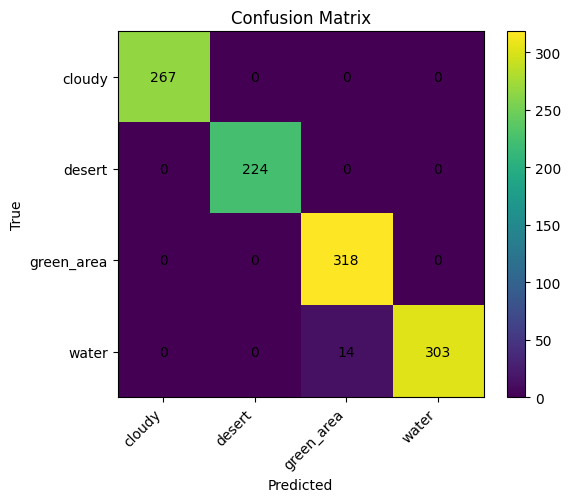

In [23]:
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(cm, interpolation='nearest')
ax.figure.colorbar(im, ax=ax)
ax.set_xticks(np.arange(NUM_CLASSES)); ax.set_yticks(np.arange(NUM_CLASSES))
ax.set_xticklabels(class_names, rotation=45, ha="right"); ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title("Confusion Matrix")
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j, i, cm[i, j], ha="center", va="center")
plt.tight_layout(); plt.show()

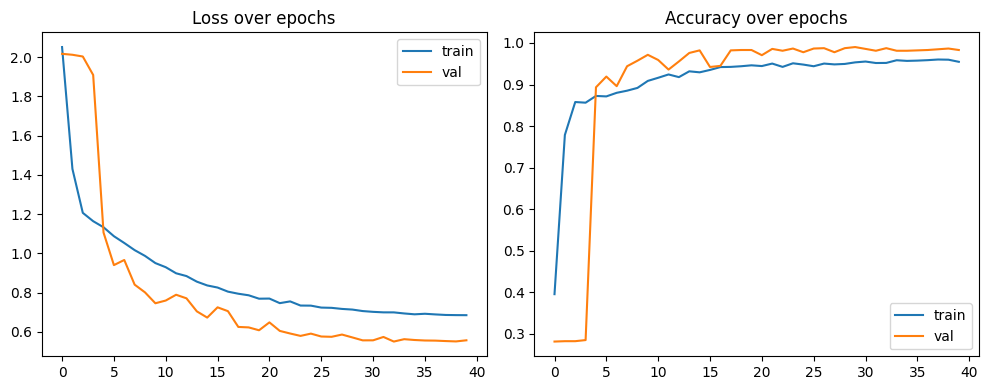

In [24]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss over epochs"); plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.title("Accuracy over epochs"); plt.legend()
plt.tight_layout()
plt.show()

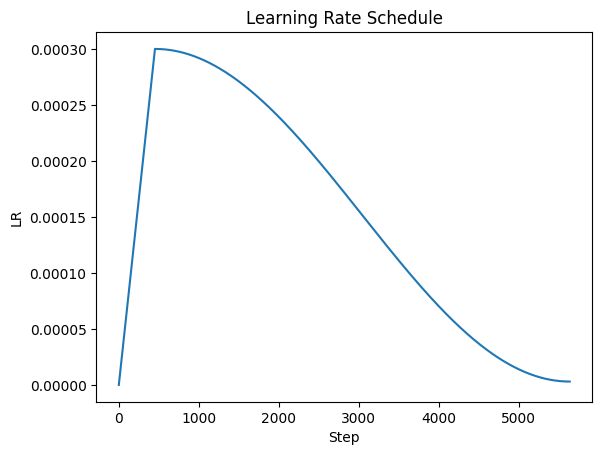

In [25]:
steps = np.arange(0, total_steps)
lrs = np.array([float(lr_schedule(int(s))) for s in steps])
plt.figure()
plt.plot(steps, lrs)
plt.title("Learning Rate Schedule"); plt.xlabel("Step"); plt.ylabel("LR")
plt.show()

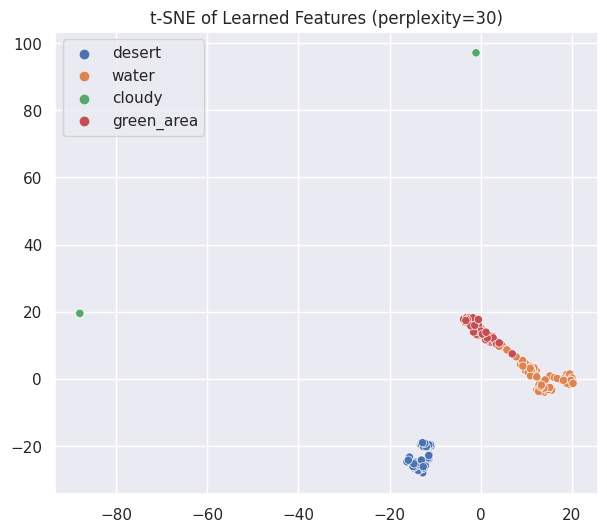

In [26]:
from sklearn.manifold import TSNE
import seaborn as sns
sns.set()
feature_extractor = tf.keras.Model(model.input, model.layers[-3].output)
features, labels = [], []
needed_batches = 10
count = 0
for imgs, lbls in val_ds:
    feats = feature_extractor.predict(imgs, verbose=0)
    features.append(feats)
    labels.append(np.argmax(lbls.numpy(), axis=1))
    count += 1
    if count >= needed_batches:
        break
features = np.concatenate(features)
labels = np.concatenate(labels)

perplexity = min(30, max(5, (features.shape[0] - 1) // 3))  # auto-safe perplexity
tsne = TSNE(n_components=2, perplexity=perplexity, learning_rate=200, random_state=SEED)
emb = tsne.fit_transform(features)
plt.figure(figsize=(7,6))
sns.scatterplot(x=emb[:,0], y=emb[:,1], hue=[class_names[i] for i in labels])
plt.title(f"t-SNE of Learned Features (perplexity={perplexity})")
plt.legend()
plt.show()

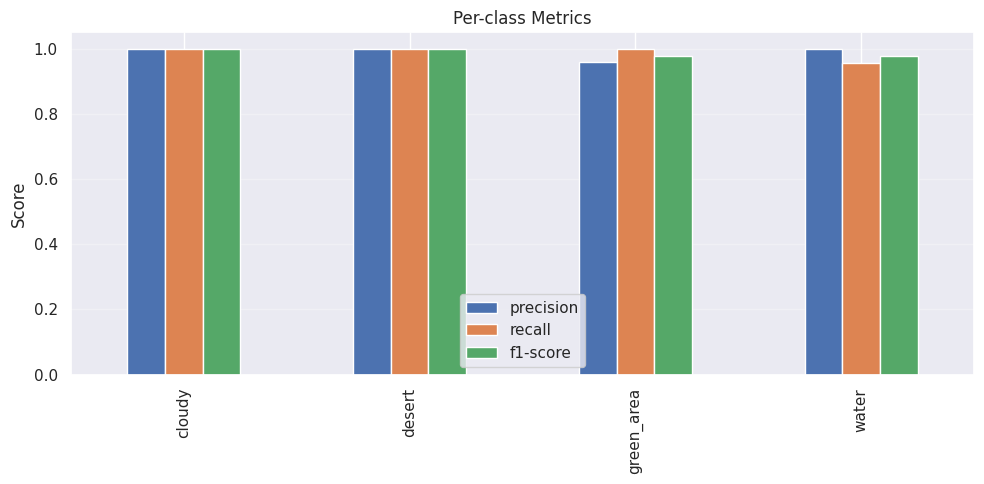

In [27]:
from sklearn.metrics import classification_report
import pandas as pd
report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
df = pd.DataFrame(report).transpose().iloc[:-3, :]  # drop micro/macro/weighted
ax = df[['precision','recall','f1-score']].plot(kind='bar', figsize=(10,5))
ax.set_title("Per-class Metrics")
ax.set_ylabel("Score")
ax.set_ylim(0.0, 1.05)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()